# HHL Algorithm

🔹 1. Imports (Qiskit 1.x)

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import QFT
from qiskit.quantum_info import SparsePauliOp

🔹 2. Define Linear System

We solve: $A∣x⟩=∣b⟩$

Example Hermitian matrix: A = $\begin{pmatrix} 1 & -1/3 \\\\ -1/3 & 1 \end{pmatrix}$ and, b = $\begin{pmatrix} 0 \\\\ 1 \end{pmatrix}$

In [3]:
A = np.array([[1, -1/3],
              [-1/3, 1]])

b = np.array([0, 1])
b = b / np.linalg.norm(b)

🔹 3. Classical Solution

In [4]:
x_classical = np.linalg.solve(A, b)
x_classical = x_classical / np.linalg.norm(x_classical)

print("Classical solution:", x_classical)

Classical solution: [0.31622777 0.9486833 ]


Classical solution: [$1/\sqrt{10},  3/\sqrt{10}$ ]

🔹 4. Convert Matrix to Quantum Operator

Instead of manually building unitaries, we use:

In [5]:
from scipy.linalg import expm
from qiskit.quantum_info import Operator

def controlled_U(circuit, clock, system, A, t=1):
    """
    Applies controlled e^{iAt}
    clock  : phase register (list of qubits)
    system : system register (target qubit)
    """

    # Compute unitary e^{iAt}
    U = expm(1j * A * t)

    # Convert to Qiskit Operator
    U_op = Operator(U)

    # Convert to instruction
    U_gate = U_op.to_instruction()

    # Create multi-controlled version
    cU = U_gate.control(num_ctrl_qubits=len(clock))

    # Append to circuit
    circuit.append(cU, list(clock) + [system[0]]) # Control on clock, target is system[0]

# Build HHL Circuit

We use:
- 1 qubit → $|b⟩$
- 2 qubits → phase estimation
- 1 ancilla → rotation

![hhl_circuit](hhl.png)

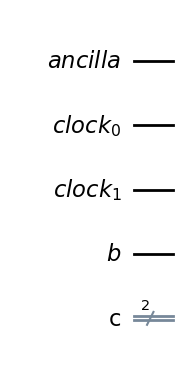

In [6]:
# Create the Quantum and Classical registers needed
clock = QuantumRegister(2, name='clock') # Register to hold the eigenvalues
b_vec = QuantumRegister(1, name='b') # Register to hold the input vector b
ancilla = QuantumRegister(1, name='ancilla') # Ancilla qubit for the controlled rotation
measurement = ClassicalRegister(2, name='c') # Classical register to hold the measurement results of the clock register

# Create an empty circuit with the specified registers
circuit = QuantumCircuit(ancilla, clock, b_vec, measurement)

circuit.draw(output='mpl')

## QFT

![qft_circuit](qft.png)

In [7]:
def qft(circ, q, n):
    """
    Apply Quantum Fourier Transform on qubits q (little-endian order).
    q[0] = least significant qubit.
    """

    # Apply QFT rotations
    for j in range(n):
        circ.h(q[j])
        for k in range(j+1, n):
            circ.cp(np.pi / (2**(k-j)), q[k], q[j])

    # Reverse qubit order
    for j in range(n // 2):
        circ.swap(q[j], q[n - j - 1])

def qft_dagger(circ, q, n):
    """
    Apply inverse Quantum Fourier Transform (QFT†)
    q[0] = least significant qubit (Qiskit little-endian)
    """

    # Step 1: Reverse qubit order
    for j in range(n // 2):
        circ.swap(q[j], q[n - j - 1])

    # Step 2: Apply inverse rotations
    for j in reversed(range(n)):
        for k in reversed(range(j+1, n)):
            circ.cp(-np.pi / (2**(k-j)), q[k], q[j])
        circ.h(q[j])

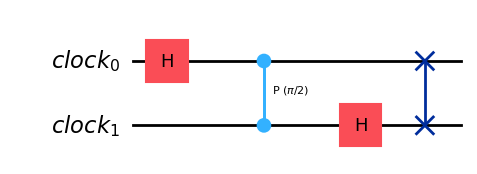

In [8]:
# draw qft and qft_dagger circuits
qft_circuit = QuantumCircuit(clock)
qft(qft_circuit, clock, len(clock))
qft_circuit.draw(output='mpl')

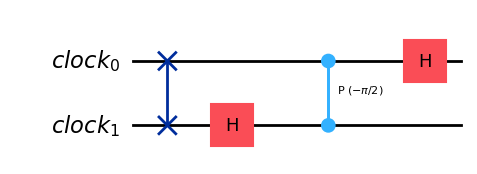

In [9]:
qft_dagger_circuit = QuantumCircuit(clock)
qft_dagger(qft_dagger_circuit, clock, len(clock))
qft_dagger_circuit.draw(output='mpl')

## QPE

![qpe_circuit](qpe.png)

In [10]:
def qpe(circuit, clock, b_vec):
    '''
    Performs quantum phase estimation to find the eigenvalues of the matrix A.
    '''
    # Perform a Hadamard Transform
    circuit.h(clock)


    # e^{i*A*t} # Apply the controlled unitary operation for time t=1
    circuit.cu(np.pi/2, -np.pi/2, np.pi/2, 3*np.pi/4, clock[0], b_vec, label='U'); 
    # controlled_U(circuit, clock, b_vec, A, t=1)
    
    # e^{i*A*t*2} # Apply the controlled unitary operation for time t=2
    circuit.cu(np.pi, np.pi, 0, 0, clock[1], b_vec, label='U2');
    # controlled_U(circuit, clock, b_vec, A, t=2)
    
    # Perform an inverse QFT on the register holding the eigenvalues
    qft_dagger(circuit, clock, 2)
    
def inv_qpe(circuit, clock, b_vec):
    
    # Perform a QFT on the register holding the eigenvalues
    qft(circuit, clock, 2)

    # e^{i*A*t*2} 
    circuit.cu(np.pi, np.pi, 0, 0, clock[1], b_vec, label='U2');
    # controlled_U(circuit, clock, b_vec, A, t=2)

    # e^{i*A*t}
    circuit.cu(np.pi/2, -np.pi/2, np.pi/2, 3*np.pi/4, clock[0], b_vec, label='U');
    # controlled_U(circuit, clock, b_vec, A, t=1)

    # Perform a Hadamard Transform
    circuit.h(clock)

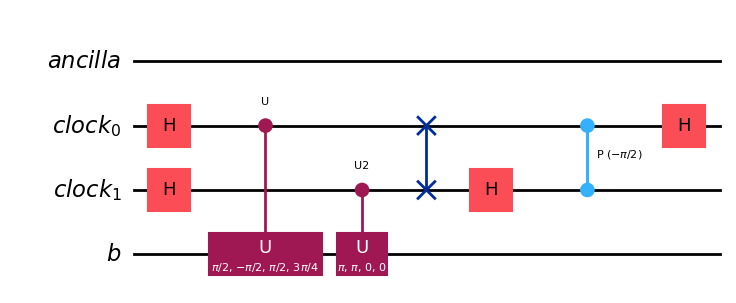

In [11]:
# draw the circuit for the phase estimation step
qpe_circuit = QuantumCircuit(ancilla, clock, b_vec)
qpe(qpe_circuit, clock, b_vec)
qpe_circuit.draw(output='mpl')

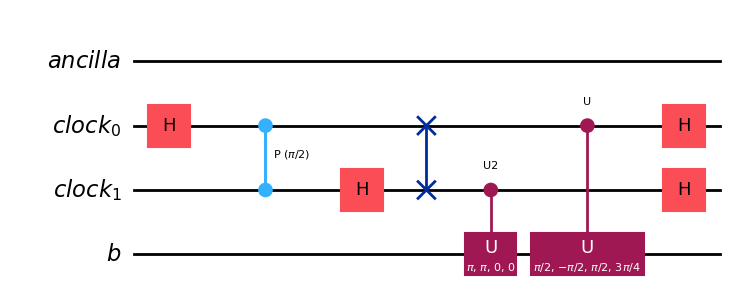

In [12]:
inverse_qpe_circuit = QuantumCircuit(ancilla, clock, b_vec)
inv_qpe(inverse_qpe_circuit, clock, b_vec)
inverse_qpe_circuit.draw(output='mpl')

In [13]:
# Function to build the HHL circuit from the major components 
def hhl(circ, ancilla, clock, b_vec, measurement):
    
    qpe(circ, clock, b_vec)
    
    #conditional Rotation
    circuit.cry(np.pi, clock[0], ancilla)
    circuit.cry(np.pi/3, clock[1], ancilla)
    
    circuit.measure(ancilla, measurement[0])
    inv_qpe(circ, clock, b_vec)

## HHL Circuit

In [14]:
# State preparation. 
intial_state = b # The state |b> is prepared in the b_vec register
circuit.initialize(intial_state, 3)

hhl(circuit, ancilla, clock, b_vec, measurement)

circuit.measure(b_vec, measurement[1])

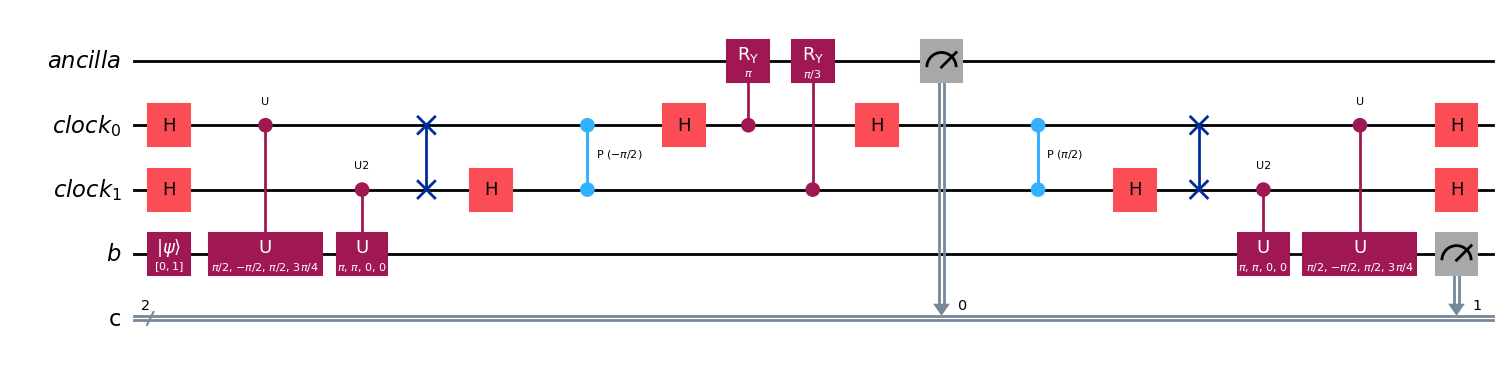

In [15]:
circuit.draw('mpl',scale=1)

In [16]:
sim = AerSimulator()
compiled_circuit = transpile(circuit, sim)
job_circuit = sim.run(compiled_circuit, shots=20000)

result_circuit = job_circuit.result()
counts_circuit = result_circuit.get_counts()

print(counts_circuit)

{'01': 6194, '00': 3760, '11': 6278, '10': 3768}


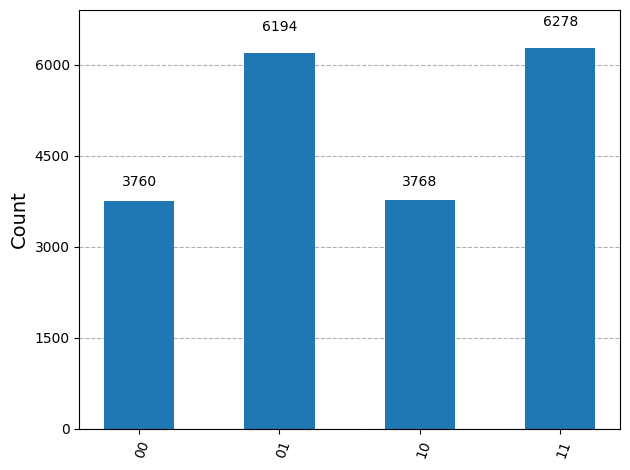

In [17]:
from qiskit.visualization import plot_histogram

plot_histogram(counts_circuit)

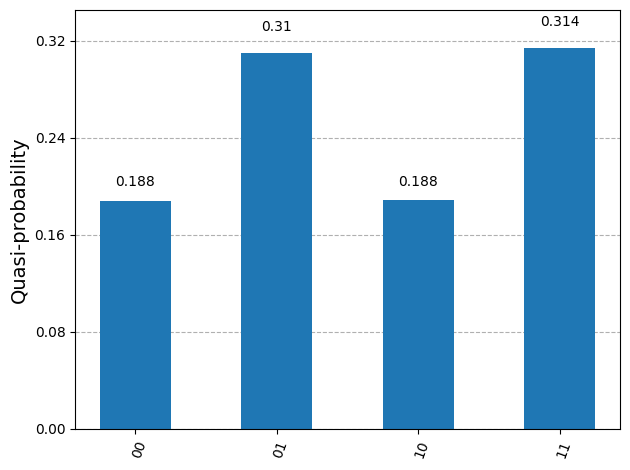

In [18]:
probabilities = {label: count / 20000 for label, count in counts_circuit.items()} # Normalize counts to probabilities
plot_histogram(probabilities)

How do we extract the solution vector ∣x⟩ from measurement counts?

In textbook HHL:
- The solution is encoded in the system register
- Conditioned on the ancilla being measured in ∣1⟩

So we must:
- Post-select on ancilla = 1
- Extract amplitudes of the system qubit 
- Normalize

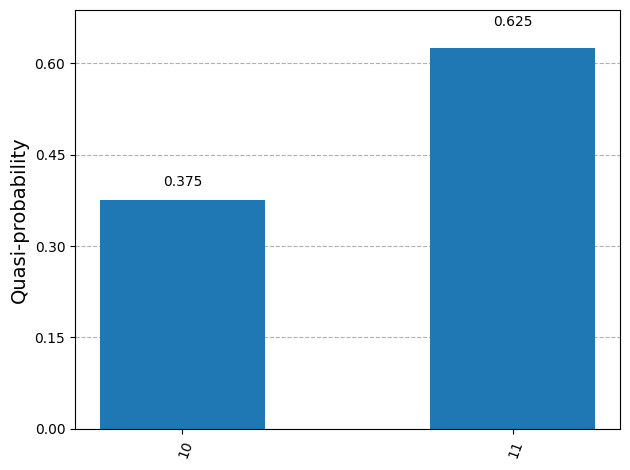

In [19]:
solution_counts = {label: count for label, count in counts_circuit.items() if label[0] == '1'} # Only consider cases where ancilla is |1>
total_solution_counts = sum(solution_counts.values()) # Total counts where ancilla is |1>
solution_probabilities = {label: count / total_solution_counts for label, count in solution_counts.items()} # Normalize to get probabilities conditioned on ancilla being |1>
plot_histogram(solution_probabilities)

In [20]:
import numpy as np

def extract_solution_from_counts(counts, n_phase, n_system=1):
    """
    Extract solution state |x> from HHL measurement counts.

    counts   : dictionary from result.get_counts()
    n_phase  : number of phase qubits
    n_system : number of system qubits (usually 1)

    Returns normalized solution vector.
    """

    solution_counts = {}

    for bitstring, count in counts.items():

        # Reverse due to Qiskit little-endian
        bitstring = bitstring[::-1]

        # Extract registers
        phase_bits = bitstring[:n_phase]
        system_bits = bitstring[n_phase:n_phase+n_system]
        ancilla_bit = bitstring[-1]

        # Post-select ancilla = 1
        if ancilla_bit == '1':

            if system_bits not in solution_counts:
                solution_counts[system_bits] = 0

            solution_counts[system_bits] += count

    # Convert counts to probability amplitudes
    total = sum(solution_counts.values())

    amplitudes = []
    for i in range(2**n_system):
        key = format(i, f'0{n_system}b')
        prob = solution_counts.get(key, 0) / total
        amplitudes.append(np.sqrt(prob))

    # Normalize
    amplitudes = np.array(amplitudes)
    amplitudes = amplitudes / np.linalg.norm(amplitudes)

    return amplitudes

In [21]:
x_quantum = extract_solution_from_counts(counts_circuit, n_phase=2)

print("Extracted quantum solution:")
print(x_quantum)

Extracted quantum solution:
[nan nan]


C:\Users\mrudu\AppData\Local\Temp\ipykernel_25120\1622775406.py:45: RuntimeWarning: invalid value encountered in divide
  amplitudes = amplitudes / np.linalg.norm(amplitudes)


In [22]:
from qiskit.quantum_info import Statevector

qc_no_measure = circuit.remove_final_measurements(inplace=False)
sv = Statevector.from_instruction(qc_no_measure)

print(sv)

Statevector([-9.15063509e-02-4.57531755e-02j,
             -3.41506351e-01+7.92468245e-02j,
              4.57531755e-02-8.27683335e-17j,
              4.20753175e-01-1.07769196e-16j,
              1.70753175e-01+3.41506351e-01j,
             -4.57531755e-02-9.15063509e-02j,
             -3.57109593e-17+1.70753175e-01j,
              4.02129141e-18-4.57531755e-02j,
              9.15063509e-02-4.57531755e-02j,
              3.41506351e-01+7.92468245e-02j,
              4.57531755e-02+2.18082070e-17j,
              4.20753175e-01-6.99539763e-17j,
              1.70753175e-01-3.41506351e-01j,
             -4.57531755e-02+9.15063509e-02j,
             -4.07196292e-17+1.70753175e-01j,
              4.32736029e-17-4.57531755e-02j],
            dims=(2, 2, 2, 2))


In [23]:
import numpy as np
from qiskit.quantum_info import Statevector

def extract_exact_solution(qc, n_phase, n_system=1):
    """
    Extract exact HHL solution |x> from statevector
    using projection onto ancilla = 1.
    
    qc         : HHL circuit (with measurements)
    n_phase    : number of phase qubits
    n_system   : number of system qubits
    
    Returns normalized solution vector.
    """

    # Remove measurements
    qc_nom = qc.remove_final_measurements(inplace=False)

    # Get statevector
    sv = Statevector.from_instruction(qc_nom)

    full_state = sv.data

    # Total qubits
    n_total = n_phase + n_system + 1

    # Reshape statevector into tensor form
    reshaped = full_state.reshape([2] * n_total)

    # Ancilla is last qubit (little endian convention)
    # Project ancilla = 1
    projected = np.take(reshaped, indices=1, axis=-1)

    # Now projected state is phase ⊗ system
    # Sum over phase register to isolate system amplitudes

    # Move system axis to front
    # phase qubits first, system after
    axes = list(range(n_phase)) + [n_phase]
    projected = np.transpose(projected, axes)

    # Reshape to (2^phase, 2^system)
    projected = projected.reshape(2**n_phase, 2**n_system)

    # Sum over phase space
    system_state = np.sum(projected, axis=0)

    # Normalize
    system_state = system_state / np.linalg.norm(system_state)

    return system_state

In [24]:
x_quantum = extract_exact_solution(circuit, n_phase=2)

print("Exact reconstructed |x> :")
print(x_quantum)

Exact reconstructed |x> :
[-0.10566243+0.1830127j   0.97168784-0.10566243j]


In [25]:
def fidelity(x_quantum, x_classical):
    x_classical = x_classical / np.linalg.norm(x_classical)
    return np.abs(np.vdot(x_classical, x_quantum))**2

In [26]:
fidelity(x_quantum, x_classical)

np.float64(0.7910683602522958)